In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from google.colab import drive
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
base_dir = '/content/drive/MyDrive/thesis-project-1'

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 123
NUM_CLASSES = 3

In [5]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    base_dir,
    validation_split=0.3,
    subset='training',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    base_dir,
    validation_split=0.3,
    subset='validation',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_size = int(0.6667 * len(val_test_ds))
val_ds = val_test_ds.take(val_size)
test_ds = val_test_ds.skip(val_size)

class_names = train_ds.class_names

print("Classes:", class_names)

Found 3015 files belonging to 3 classes.
Using 2111 files for training.
Found 3015 files belonging to 3 classes.
Using 904 files for validation.
Classes: ['BEVERAGE', 'SNACK', 'STAPLE']


In [6]:
from tensorflow.keras.applications.resnet50 import preprocess_input
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y)).prefetch(AUTOTUNE)
val_ds   = val_ds.map(lambda x, y: (preprocess_input(x), y)).prefetch(AUTOTUNE)
test_ds  = test_ds.map(lambda x, y: (preprocess_input(x), y)).prefetch(AUTOTUNE)




In [7]:
base_model = ResNet50(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze base model first
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,113,027 (91.98 MB)

 Trainable params: 525,315 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [8]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=2,
        verbose=1
    ),
    ModelCheckpoint(
        'best_resnet50.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

In [9]:
initial_epochs = 20

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=initial_epochs,
    callbacks=callbacks
)

Epoch 1/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.3682 - loss: 1.3920
Epoch 1: val_accuracy improved from None to 0.41447, saving model to best_resnet50.keras

Epoch 1: finished saving model to best_resnet50.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 632s 9s/step - accuracy: 0.3847 - loss: 1.2432 - val_accuracy: 0.4145 - val_loss: 1.0351 - learning_rate: 0.0010
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.4188 - loss: 1.0734
Epoch 2: val_accuracy improved from 0.41447 to 0.47368, saving model to best_resnet50.keras

Epoch 2: finished saving model to best_resnet50.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 592s 9s/step - accuracy: 0.4249 - loss: 1.0705 - val_accuracy: 0.4737 - val_loss: 1.0160 - learning_rate: 0.0010
Epoch 3/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.4176 - loss: 1.0626
Epoch 3: val_accuracy improved from 0.47368 to 0.51151, saving model to best_resnet50.keras

Epoch 3: finished saving model to best_resnet50.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 582s 9

In [11]:
base_model.trainable = True

# Freeze most layers, unfreeze last part
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

fine_tune_epochs = 10

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=initial_epochs + fine_tune_epochs,
    initial_epoch=history.epoch[-1] + 1,
    callbacks=callbacks
)

Epoch 21/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.5696 - loss: 0.9879
Epoch 21: val_accuracy did not improve from 0.59868
66/66 ━━━━━━━━━━━━━━━━━━━━ 811s 12s/step - accuracy: 0.5983 - loss: 0.8928 - val_accuracy: 0.3438 - val_loss: 1.8092 - learning_rate: 1.0000e-05
Epoch 22/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.7027 - loss: 0.6205
Epoch 22: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.

Epoch 22: val_accuracy did not improve from 0.59868
66/66 ━━━━━━━━━━━━━━━━━━━━ 778s 12s/step - accuracy: 0.7058 - loss: 0.6069 - val_accuracy: 0.4046 - val_loss: 2.0484 - learning_rate: 1.0000e-05
Epoch 23/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.7455 - loss: 0.5491
Epoch 23: val_accuracy did not improve from 0.59868
66/66 ━━━━━━━━━━━━━━━━━━━━ 821s 12s/step - accuracy: 0.7428 - loss: 0.5419 - val_accuracy: 0.4622 - val_loss: 1.3851 - learning_rate: 2.0000e-06
Epoch 24/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.7601 - los

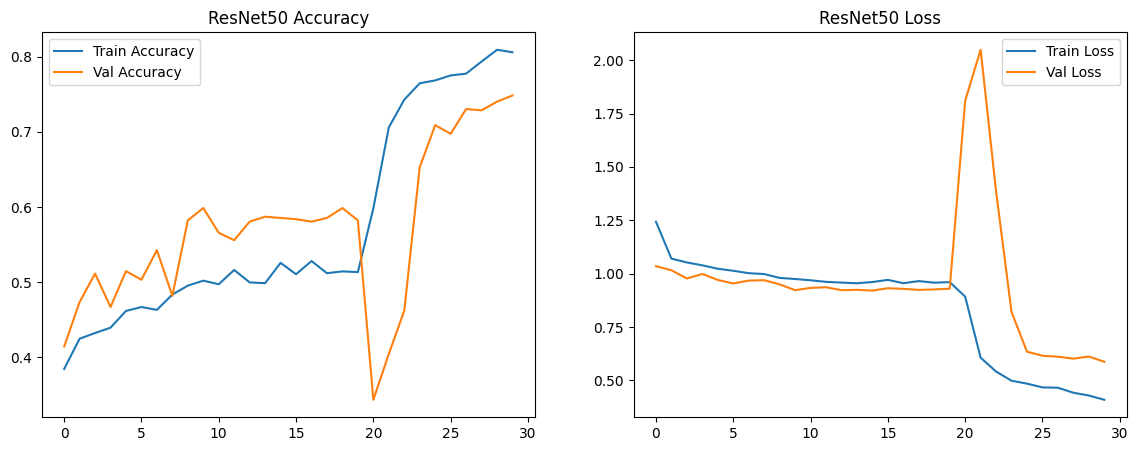

In [12]:
acc = history.history['accuracy'] + history_fine.history['accuracy']
val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']

loss = history.history['loss'] + history_fine.history['loss']
val_loss = history.history['val_loss'] + history_fine.history['val_loss']

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.title('ResNet50 Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.title('ResNet50 Loss')
plt.legend()

plt.show()

In [13]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

10/10 ━━━━━━━━━━━━━━━━━━━━ 84s 7s/step - accuracy: 0.7230 - loss: 0.6082
Test Loss: 0.60821133852005
Test Accuracy: 0.7229729890823364


In [14]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

    BEVERAGE       0.87      0.87      0.87        97
       SNACK       0.69      0.68      0.68       109
      STAPLE       0.67      0.68      0.67        90

    accuracy                           0.74       296
   macro avg       0.74      0.74      0.74       296
weighted avg       0.74      0.74      0.74       296



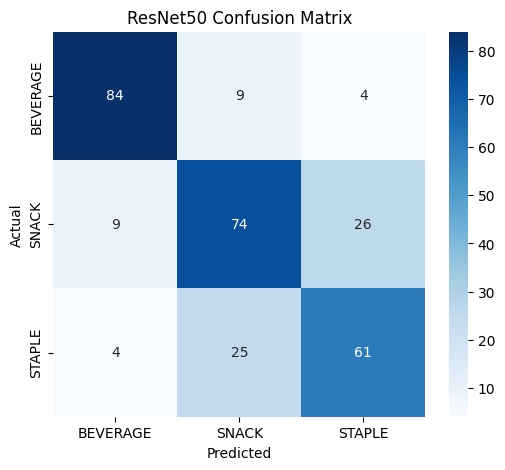

In [15]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ResNet50 Confusion Matrix")
plt.show()

In [16]:
model.save('/content/drive/MyDrive/resnet50_meal_classifier.keras')